# Table of Content
* 1. [libraries](#1)
* 2. [Datasets](#2)
* 3. [Feature Engineering](#3)
* 4. [Exploratery Data Analysis](#4)
      * 4.1 [Statistical Analysis](#4.1)
      * 4.2 [Top Countries with Heighest Annual Income](#4.2)
      * 4.3 [Countries With Lowest Corruption](#4.3)
      * 4.4 [Countries With Lowest Unemployment](#4.3)
      * 4.5 [Countries With Heighest Gdp per capita](#4.5)
      * 4.6 [Countries With lowest Cost Index](#4.6)
      * 4.7 [Relation b/w GDP per capita and annul income](#4.7)
      * 4.8 [Relation b/w purchasing power index and annual income](#4.8)
      * 4.9 [Relation b/w purchasing power index and cost index](#4.9)
      * 4.10 [Relation b/w purchasing power index and gdp per capita](#4.10)
      * 4.11 [Relation /w corruption index and annual income](#4.11)
      * 4.12 [Relation /w corruption index and annual unemployment](#)
      * 4.13 [](#)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
corr =pd.read_csv('corruption.csv')
col=pd.read_csv('cost_of_living.csv')
rich_countery = pd.read_csv('richest_countries.csv')
tourism = pd.read_csv("tourism.csv")
unempl = pd.read_csv("unemployment.csv")

In [3]:
corr.head(5)

,country,annual_income,corruption_index
0,Denmark,68110,12
1,Finland,53660,12
2,New Zealand,45340,12
3,Norway,84090,15
4,Singapore,64010,15


In [4]:
corr.isnull().sum()

country             0
annual_income       0
corruption_index    0
dtype: int64

In [5]:
col.head(5)

,country,cost_index,monthly_income,purchasing_power_index
0,Bermuda,157.6,9712,105.0
1,Switzerland,142.4,7530,90.1
2,Cayman Islands,137.9,5281,65.2
3,Israel,130.2,4130,54.1
4,Iceland,128.0,5368,71.5


In [6]:
col.isnull().sum()

country                   0
cost_index                0
monthly_income            0
purchasing_power_index    0
dtype: int64

In [7]:
rich_countery.head(5)

,country,gdp_per_capita
0,Luxembourg,134754
1,Singapore,116486
2,Ireland,106456
3,Qatar,93521
4,Bermuda,85192


In [8]:
rich_countery.isnull().sum()

country           0
gdp_per_capita    0
dtype: int64

In [9]:
tourism.head(5)

,country,tourists_in_millions,receipts_in_billions,receipts_per_tourist,percentage_of_gdp
0,France,117.1,35.96,307,1.2
1,Mexico,51.1,11.45,224,0.9
2,United States,45.0,84.21,1870,0.4
3,Italy,38.4,20.46,533,1.0
4,Hungary,31.6,4.22,133,2.3


In [10]:
unempl.head(5)

,country,unemployment_rate
0,Marshall Islands,36.0
1,South Africa,33.6
2,Kiribati,30.6
3,Kosovo,30.5
4,American Samoa,29.8


# 3. Feature Engineering <span id='3'></span>

## 3.1 Merging All dataset in one <span id='3.1'></span>

In [11]:
from functools import reduce
dfs = [corr,col,rich_countery,tourism,unempl]
df = reduce(lambda left, right: pd.merge(left, right, on='country'), dfs)

In [12]:
df

,country,annual_income,corruption_index,cost_index,monthly_income,purchasing_power_index,gdp_per_capita,tourists_in_millions,receipts_in_billions,receipts_per_tourist,percentage_of_gdp,unemployment_rate
0,Norway,84090,15,124.6,7008,95.9,79201,1.4,2.20,1572,0.5,5.0
1,Netherlands,56370,18,99.0,4698,80.8,63767,7.3,10.93,1504,1.1,4.0
2,Luxembourg,81110,19,113.1,6759,101.8,134754,0.5,4.45,8484,5.1,5.2
3,Germany,51040,20,92.3,4253,78.5,57928,12.4,58.37,4689,1.4,3.5
4,Hong Kong,54450,24,77.9,4538,99.2,65973,3.6,32.70,9161,8.9,5.3
5,Australia,56760,27,118.0,4730,68.3,55807,1.8,26.23,14351,1.7,5.1
6,Japan,42620,27,101.9,3552,59.4,42940,4.1,11.40,2769,0.2,2.8
7,France,43880,29,96.2,3657,64.7,50729,117.1,35.96,307,1.2,8.1
8,United States,70430,33,100.0,5869,100.0,69288,45.0,84.21,1870,0.4,5.5
9,Qatar,57120,37,71.4,4760,113.6,93521,0.6,14.32,24601,8.0,0.3


# 4. Exploratery Data Analysis <span id='4'></span>

## 4.1 statical Analysis <span id='3.2'></span>

In [13]:
df.isnull().sum()

country                   0
annual_income             0
corruption_index          0
cost_index                0
monthly_income            0
purchasing_power_index    0
gdp_per_capita            0
tourists_in_millions      0
receipts_in_billions      0
receipts_per_tourist      0
percentage_of_gdp         0
unemployment_rate         0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.describe()

,annual_income,corruption_index,cost_index,monthly_income,purchasing_power_index,gdp_per_capita,tourists_in_millions,receipts_in_billions,receipts_per_tourist,percentage_of_gdp,unemployment_rate
count,16.000000,16.000000,16.00000,16.000000,16.000000,16.000000,16.00000,16.000000,16.000000,16.000000,16.00000
mean,45268.750000,35.625000,85.06250,3772.500000,71.506250,58581.500000,16.84375,21.221250,4832.187500,2.231250,6.03125
std,23284.276776,16.788389,27.03908,1940.391919,24.758203,27033.593748,29.77491,22.560991,6611.774993,2.717283,3.78677
min,9830.000000,15.000000,34.40000,819.000000,38.300000,30472.000000,0.50000,1.610000,307.000000,0.200000,0.30000
25%,31270.000000,23.000000,73.87500,2605.750000,54.000000,41058.500000,2.32500,5.882500,822.000000,0.575000,3.87500
50%,47460.000000,31.000000,89.65000,3955.000000,66.500000,53268.000000,5.70000,12.775000,1721.000000,1.150000,5.15000
75%,56850.000000,45.750000,100.47500,4737.500000,96.725000,66801.750000,13.30000,27.847500,5637.750000,2.000000,6.15000
max,84090.000000,71.000000,124.60000,7008.000000,113.600000,134754.000000,117.10000,84.210000,24601.000000,8.900000,14.80000


## 4.2 Top Countries with Heighest Annual Income <span id='4.2'></span>

<Axes: xlabel='country'>

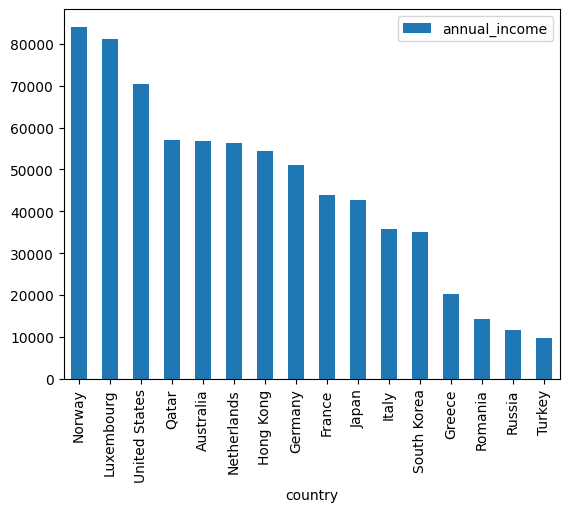

In [16]:
df.sort_values(by='annual_income',ascending=False).plot(kind='bar',x='country',y='annual_income')

#### <span style="color:deepskyblue">In Developed countries Peoples have Height Annual income  </span>

## 4.3 Countries With Lowest Corruption <span id='4.3'></span>

<Axes: xlabel='country'>

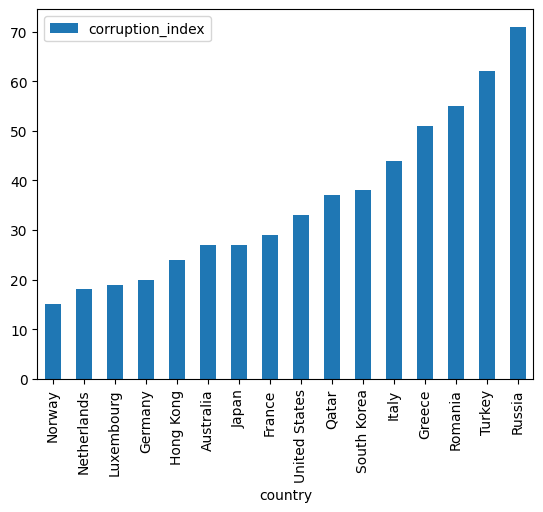

In [17]:
df.sort_values(by='corruption_index',ascending=True).plot(kind='bar',x='country',y='corruption_index')

#### <span style="color:deepskyblue">Developed countries have lowest corruption  </span>

## 4.4 Countries With Lowest Unemployment <span id='4.4'></span>


<Axes: xlabel='country'>

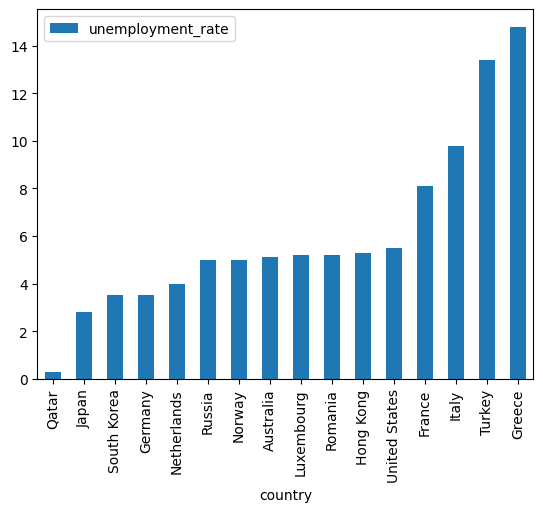

In [18]:
df.sort_values(by='unemployment_rate',ascending=True).plot(kind='bar',x='country',y='unemployment_rate')

## 4.5 Countries With Heighest Gdp per capita <span id='4.5'></span>


<Axes: xlabel='country'>

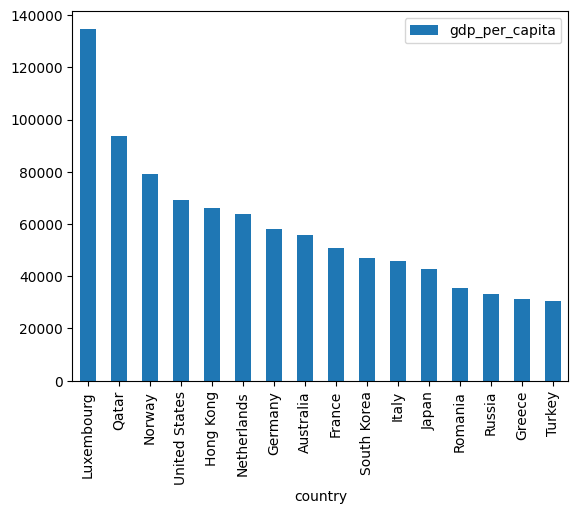

In [19]:
df.sort_values(by='gdp_per_capita',ascending=False).plot(kind='bar',x='country',y='gdp_per_capita')

## 4.6 Countries With Heightest cost Index <span id='4.6'></span>

<Axes: xlabel='country'>

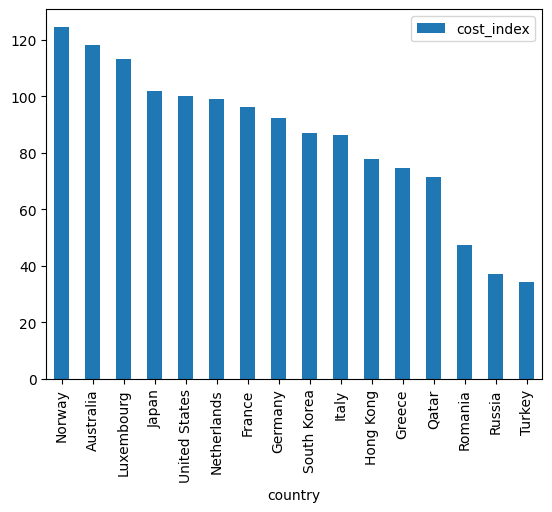

In [20]:
df.sort_values(by='cost_index',ascending=False).plot(kind='bar',x='country',y='cost_index')

## 4.7 Relation b/w GDP per capita and annul income <span id='4.7'></span>


C:\Users\user\AppData\Local\Temp\ipykernel_14560\586220008.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['annual_income'],hist=False,label='Annual Income')
C:\Users\user\AppData\Local\Temp\ipykernel_14560\586220008.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df

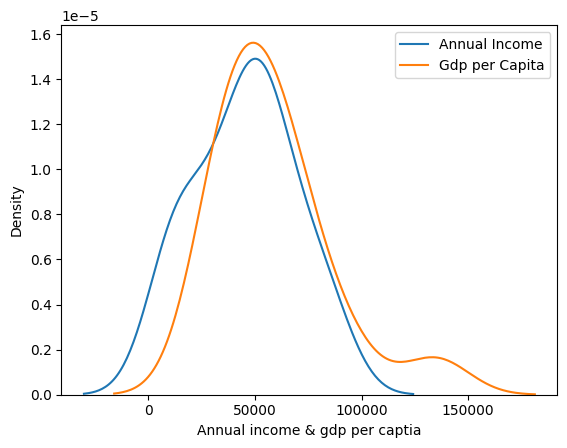

In [21]:
sns.distplot(df['annual_income'],hist=False,label='Annual Income')
sns.distplot(df['gdp_per_capita'],hist=False,label='Gdp per Capita')
plt.xlabel("Annual income & gdp per captia")
plt.legend()
plt.show()

<Axes: xlabel='annual_income', ylabel='gdp_per_capita'>

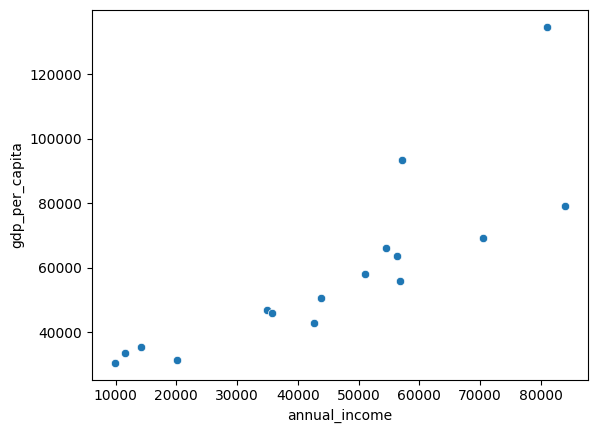

In [22]:
sns.scatterplot(x=df['annual_income'],y=df['gdp_per_capita'])

## 4.8 Relation b/w purchasing power index and annual income <span id='4.8'></span>


<Axes: xlabel='annual_income', ylabel='purchasing_power_index'>

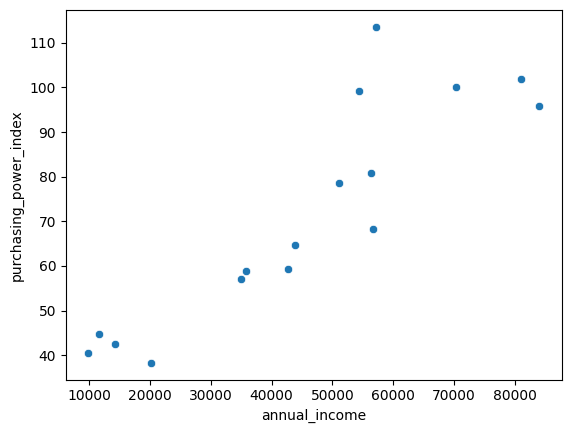

In [23]:
sns.scatterplot(x=df['annual_income'],y=df['purchasing_power_index'])

In [24]:
df['annual_income_in_k'] = df['annual_income'].apply(lambda x:x/1000)

C:\Users\user\AppData\Local\Temp\ipykernel_14560\2055699531.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['annual_income_in_k'],hist=False,label='Annual Income')
C:\Users\user\AppData\Local\Temp\ipykernel_14560\2055699531.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.dist

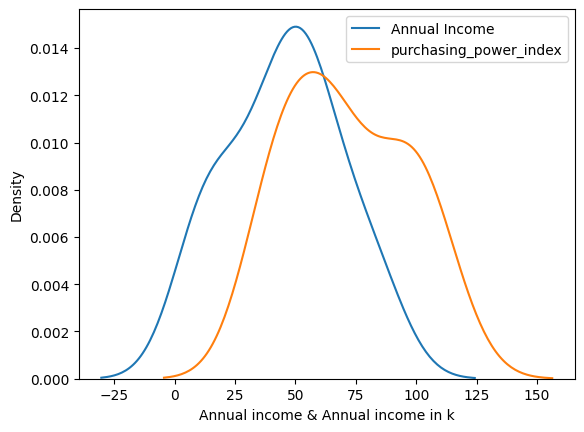

In [25]:
sns.distplot(df['annual_income_in_k'],hist=False,label='Annual Income')
sns.distplot(df['purchasing_power_index'],hist=False,label='purchasing_power_index')
plt.xlabel("Annual income & Annual income in k")
plt.legend()
plt.show()

#### <span style='color:deepskyblue'>Countries With Heigh Annual income Hase Heigh purchasing power</span>

## 4.9 Relation b/w purchasing power index and cost index <span id='4.9'></span>


C:\Users\user\AppData\Local\Temp\ipykernel_14560\3463694178.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['cost_index'],hist=False,label='cost_index')
C:\Users\user\AppData\Local\Temp\ipykernel_14560\3463694178.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['pu

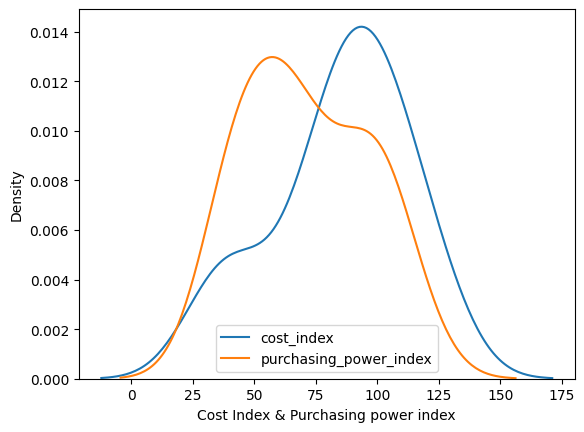

In [26]:
sns.distplot(df['cost_index'],hist=False,label='cost_index')
sns.distplot(df['purchasing_power_index'],hist=False,label='purchasing_power_index')
plt.xlabel("Cost Index & Purchasing power index")
plt.legend()
plt.show()

#### <span style='color:deepskyblue'>Countries With purchasing power have Heigh cost index</span>

## 4.10 Relation b/w purchasing power index and gdp per capita <span id='4.10'></span>


In [27]:
df['gdp_per_capita_in_k']=df['gdp_per_capita'].apply(lambda x:x/1000)

C:\Users\user\AppData\Local\Temp\ipykernel_14560\3021032.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['gdp_per_capita_in_k'],hist=False,label='gdp_per_capita_in_k')
C:\Users\user\AppData\Local\Temp\ipykernel_14560\3021032.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.dis

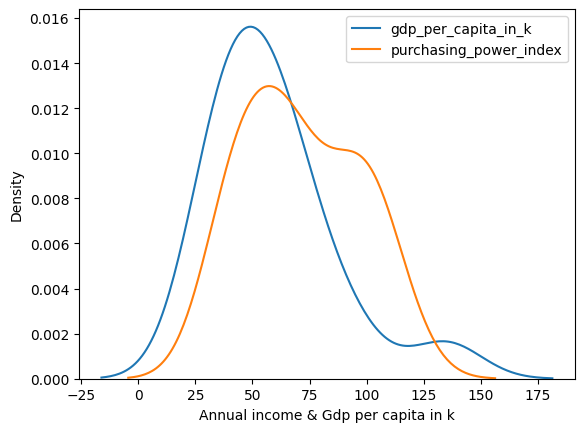

In [28]:
sns.distplot(df['gdp_per_capita_in_k'],hist=False,label='gdp_per_capita_in_k')
sns.distplot(df['purchasing_power_index'],hist=False,label='purchasing_power_index')
plt.xlabel("Annual income & Gdp per capita in k")
plt.legend()
plt.show()

<Axes: xlabel='purchasing_power_index', ylabel='gdp_per_capita_in_k'>

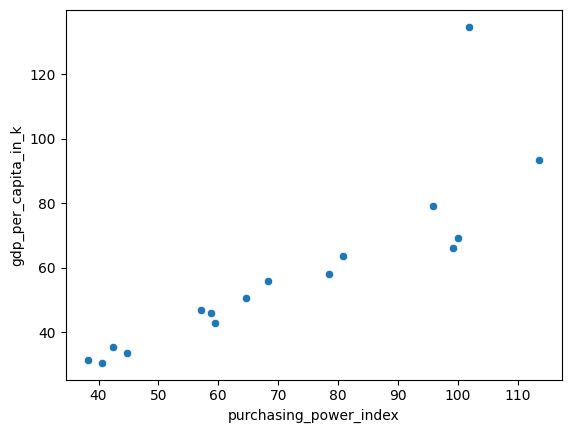

In [29]:
sns.scatterplot(y=df['gdp_per_capita_in_k'],x=df['purchasing_power_index'])

## 4.11 Relation /w corruption index and annual income <span id='4.11'></span>


<Axes: xlabel='corruption_index', ylabel='annual_income'>

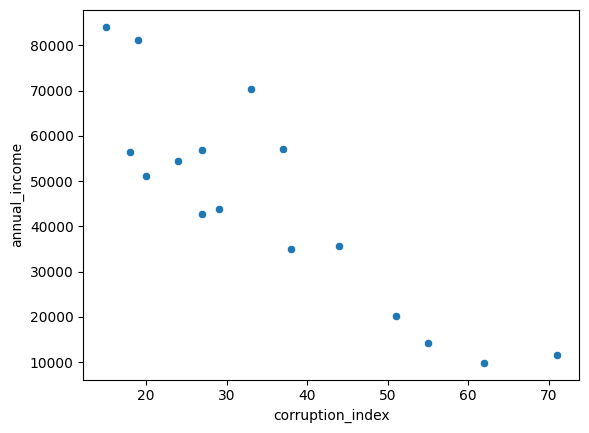

In [30]:
sns.scatterplot(y=df['annual_income'],x=df['corruption_index'])

## 4.12 Relation /w corruption index and unemployment <span id='4.12'></span>

<Axes: xlabel='unemployment_rate', ylabel='corruption_index'>

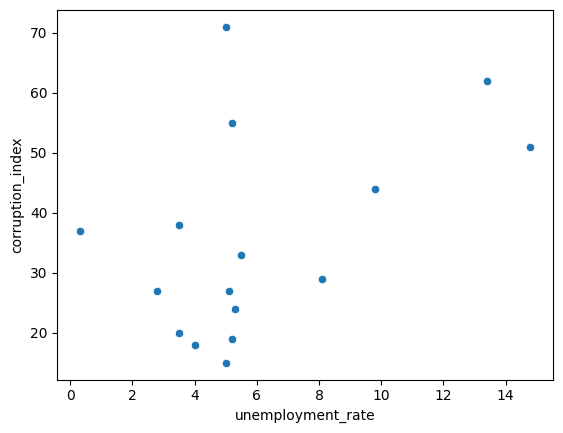

In [31]:
sns.scatterplot(x=df['unemployment_rate'],y=df['corruption_index'])